<div style="border-left: 8px solid #1A365D; border-right: 2px solid #E2E8F0; border-top: 2px solid #E2E8F0; border-bottom: 2px solid #E2E8F0; padding: 25px; border-radius: 4px; background-color: #F8FAFC; font-family: 'Segoe UI', Arial, sans-serif; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.05);">
    <span style="color: #D69E2E; font-weight: bold; letter-spacing: 1.5px; font-size: 0.9em; text-transform: uppercase;">FES Acatlán • UNAM</span>
    <h1 style="color: #1A365D; font-size: 2.2em; font-weight: 700; margin-top: 5px; margin-bottom: 5px; line-height: 1.2;">Diplomado en Técnicas Estadísticas y Minería de Datos</h1>
    <h3 style="color: #4A5568; font-size: 1.3em; font-weight: 400; margin-top: 0; margin-bottom: 20px;">Módulo II: Modelos Estadísticos</h3>
    <hr style="border: 0; height: 1px; background: #CBD5E0; margin-bottom: 20px;">
    <table style="width: 100%; border-collapse: collapse; font-size: 0.95em; color: #4A5568;">
        <tr>
            <td style="padding: 4px 0; width: 50%;"><strong>Notebook:</strong> Variables aleatorias (absolutamente) continuas </td>
            <td style="padding: 4px 0; width: 50%; text-align: right;"><strong>Estudiante:</strong> Blanca Sánchez Germán</td>
        </tr>
        <tr>
            <td style="padding: 4px 0;"><strong>Profesora:</strong> Act. Claudia C. Reyes Montes de Oca</td>
            <td style="padding: 4px 0; text-align: right;"><strong>Fecha:</strong> 24 y 27 de Junio 2026</td>
        </tr>
    </table>
</div>

# Variables aleatorias (absolutamente) continuas

**Definición.** Una variable aleatoria absolutamente continua es aquella para la cual existe una función $f_X$ no negativa, llamada función de densidad, tal que:
$$
F_X(x) = \mathbb{P}(X\leq x) = \int_{-\infty}^{x} f_X(y) dy, \quad x\in \mathbb{R}
$$

**Lema.** Sea $F_X$ una función de distribución. Supongamos que $F_X$ es derivable y que su derivada es continua en $(a, b)$, donde:
$ a = \inf \{ x \in \mathbb{R} \mid F_X(x) > 0 \}, \quad b = \sup \{ x \in \mathbb{R} \mid F_X(x) < 1 \}$
entonces, la función de densidad se puede obtener como:
$$ f_X(x) =
\begin{cases} 
F'_X(x), & \text{si } x \in (a, b), \\
0, & \text{e.o.c.}
\end{cases}$$

Es decir,
$$ \frac{dF_X(x)}{dx} = f_X(x)$$


**Esperanza Matemática**
$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot f_X(x) \,dx$$


#### *Dispersión y Momentos*

 **Varianza**
La varianza mide qué tan lejos están los valores de su centro de masa $\mathbb{E}[X]$:
$$Var(X) = \mathbb{E}\left[(X - \mathbb{E}[X])^2\right] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

**Lema del Estadístico Inconsciente (LOTUS)**
Para una función $g(X)$:
* $\mathbb{E}[g(X)] = \int_{-\infty}^{\infty} g(x) \cdot f_X(x) \,dx$

**Función Generadora de Momentos (FGM)**
$$M_X(t) = \mathbb{E}[e^{tX}]$$


In [6]:
import numpy as np # Importamos Numpy
import numpy.random as npr # para generar numeros aleatorios

import scipy.stats as sps # Importamos el modulo SciPy
from scipy.stats import randint # para trabajar una uniforme discreta en un rango de enteros

import matplotlib.pyplot as plt #Visualizar datos 

import random # para generar numeros aleatorios

## Variable aleatoria uniforme (rectangular) sobre el intervalo $(a,b)$.

Una variable aleatoria $X$ se dice que tiene distribución uniforme continua  en el intervalo $(a,b)$ con $a,b\in\mathbb{R}$, si su función de densidad esta dada por:
$$f_{X}(x)=\begin{cases}
	\frac{1}{b-a} &\quad \text{si } a< x < b\\
	\qquad 0 &\quad \text{en otro caso}  
\end{cases}$$

**Notación.** $X\sim \text{Unif}(a,b)$ $\text{Unif}[a,b]$

**Obs:**
* La distribución uniforme continua en $(a,b)$ es simétrica.
* A los intervalos de la misma longitud contenidos en $(a,b)$ se les asigna la misma probabilidad. Esto se representa gráficamente con la probabilidad de que $X$ se encuentre en el intervalo $(s,t)$:


La función de distribución de $X\sim Unif((a,b))$ esta dada por:
$$F_{X}(x)=\begin{cases}
	 0 &\quad \text{si } x\le a \\
	\frac{x-a}{b-a} &\quad \text{si } a<x<b\\
	 1 &\quad \text{si } x\ge b  
\end{cases}$$

La esperanza de una variable aleatoria uniforme es la siguiente,
$$\begin{align*}
\mathbb{E}[X] &= \int_{a}^{b}xf_{X}(x)dx = \int_{a}^{b}x\frac{1}{b-a}dx = \frac{1}{b-a}\int_{a}^{b}xdx  = \frac{1}{b-a}\left[\frac{x^{2}}{2}\right]_{a}^{b} \\ &= \frac{1}{b-a}\left[\frac{b^{2}}{2}-\frac{a^{2}}{2}\right] =  \frac{b^{2}-a^{2}}{2(b-a)} = \frac{(b-a)(b+a)}{2(b-a)} = \frac{a+b}{2}.
\end{align*}$$

Para calcular la varianza, primero vamos a calcular el segundo momento
$$\begin{align*}
\mathbb{E}[X^{2}] &= \int_{a}^{b}x^{2}f_{X}(x)dx = \int_{a}^{b}x^{2}\frac{1}{b-a}dx = \frac{1}{b-a}\int_{a}^{b}x^{2}dx \\ &= \frac{1}{b-a}\left[\frac{x^{3}}{3}\right]_{a}^{b} = \frac{1}{b-a}\left[\frac{b^{3}}{3}-\frac{a^{3}}{3}\right] =  \frac{b^{3}-a^{3}}{3(b-a)}.
\end{align*}$$

Por lo que se tiene lo siguiente

$$Var(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} =\frac{b^{3}-a^{3}}{3(b-a)}-\left(\frac{a+b}{2}\right)^{2} = \frac{(b-a)^{2}}{12}.$$


A diferencia de las variables discretas, en una distribución continua la probabilidad de que la variable tome un valor exacto es cero: $\mathbb{P}(X = x) = 0$. En su lugar, calculamos la probabilidad de que $X$ caiga dentro de un intervalo $(s, t)$ calculando el área bajo la función de densidad $f_X(x)$.

* **Función de Densidad ($f_X(x)$):** Es una línea completamente horizontal a una altura constante de $\frac{1}{b-a}$. Esto refleja que todos los subintervalos de la misma longitud tienen exactamente la misma probabilidad de ocurrir. El área total del rectángulo formado entre $a$ y $b$ es siempre igual a $1$.
* **Función Acumulada ($F_X(x)$):** Como se observa en el desarrollo matemático, representa una rampa lineal creciente que inicia en $0$ (cuando $x \le a$) y llega uniformemente hasta $1$ (cuando $x \ge b$).

####  **Nota (`scipy.stats.uniform`)**
En Python, la función `uniform` **no recibe los parámetros** $a$ (límite inferior) y $b$ (límite superior) directamente. En su lugar, utiliza la estructura:
`uniform(loc, scale)`

Donde la correspondencia matemática exacta con tu libreta es:
* `loc` = $a$ (el punto de inicio del intervalo).
* `scale` = $b - a$ (la longitud o ancho total del intervalo).

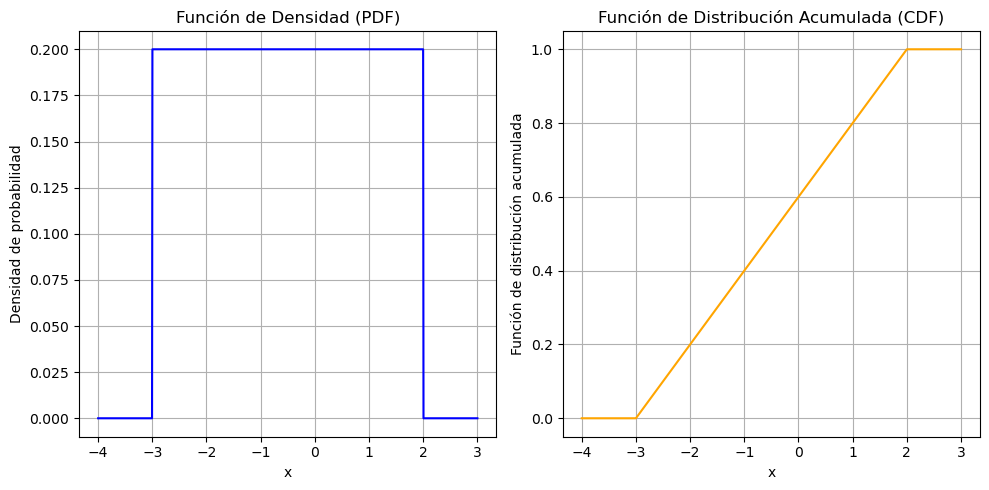

In [7]:
# Parámetros de la distribución uniforme
a = -3  # límite inferior
b = 2  # límite superior

# Definimos las funciones de densidad y distribución
# Función de densidad (pdf) de la distribución uniforme
def uniform_pdf(x, a, b):
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0)

# Función de distribución (cdf) de la distribución uniforme
def uniform_cdf(x, a, b):
    return np.where(x < a, 0, np.where(x > b, 1, (x - a) / (b - a)))
    
# Generar valores de x
x = np.linspace(-4, 3, 1000)

# Calcular la función densidad 
pdf_values = uniform_pdf(x, a, b)

# Calcular la función de distribución
cdf_values = uniform_cdf(x, a, b)

# Graficar la PDF
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_values, label='PDF', color='blue') # para cada gráfica
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad (PDF)')
plt.grid(True)

# Graficar la CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf_values, label='CDF', color='orange')
plt.xlabel('x')
plt.ylabel('Función de distribución acumulada')
plt.title('Función de Distribución Acumulada (CDF)')
plt.grid(True)

plt.tight_layout()
plt.show()

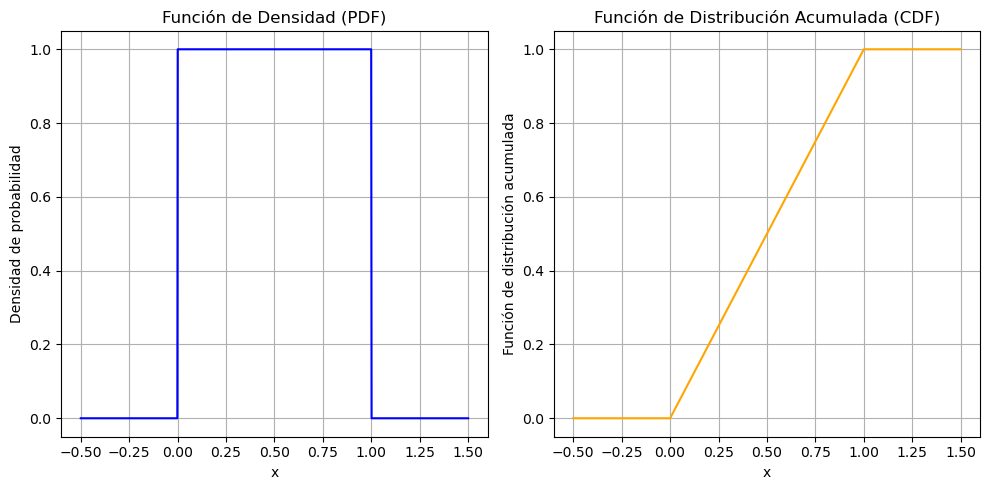

In [4]:
from scipy.stats import uniform

# Parámetros de la distribución uniforme
a = 0  # límite inferior
b = 1  # límite superior

# Crear el objeto de distribución uniforme usando scipy
uniform_dist = uniform(loc=a, scale=b-a)

# Generar valores de x
x = np.linspace(-0.5, 1.5, 1000)

# Calcular la PDF usando scipy
pdf_values = uniform_dist.pdf(x)

# Calcular la CDF usando scipy
cdf_values = uniform_dist.cdf(x)

# Graficar la PDF
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_values, label='PDF', color='blue')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad (PDF)')
plt.grid(True)

# Graficar la CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf_values, label='CDF', color='orange')
plt.xlabel('x')
plt.ylabel('Función de distribución acumulada')
plt.title('Función de Distribución Acumulada (CDF)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Ejemplo.** 	Sea $X\sim Unif((-3,2))$. Vamos a calcular: $P(X\ge 0)$ y
$P(-5 \le X \le 1/2)$.

**Solución.** La función de densidad de esta variable aleatoria esta dada por:
$$f_{X}(x)=\begin{cases}
	\quad \frac{1}{5} &\quad \text{si } -3\le x \le 2\\
	\quad 0 &\quad \text{e.o.c}  
\end{cases}$$
Entonces,

$$\begin{align}
\mathbb{P}(X\ge 0) &= \int_{0}^{2}\frac{1}{5}dx=\frac{1}{5}x\Big|_{0}^{2}=\frac{2}{5} \\
\mathbb{P}(-5 \le X \le 1/2) &= \int_{-5}^{-3}f_{X}(x)dx+\int_{-3}^{1/2}\frac{1}{5}dx=\frac{1}{5}x\Big|_{-3}^{1/2}=\frac{1}{5}\left(\frac{1}{2}+3\right)=\frac{7}{10}
\end{align}$$

Utilizando la $F_X$, 
$$F_X(x):=\mathbb{P}(X\le x)$$
se tiene:

- $\mathbb{P}(X\ge 0)=1-F_X(0)$ 
- $\mathbb{P}(-5\le X \le 1/2) = F_{X}(1/2)-F_{X}(-5)$

In [9]:
from scipy.stats import uniform

# Parámetros de la distribución uniforme
a = -3  # límite inferior
b = 2   # límite superior

# Crear el objeto de distribución uniforme usando scipy
uniform_dist = uniform(loc=a, scale=b-a)

# Calcular P(X >= 0) = 1 - P(X < 0)
p_0 = 1 - uniform_dist.cdf(0)

# Calcular P(-5 <= X <= 1/2)
p_interval = uniform_dist.cdf(1/2) - uniform_dist.cdf(-5)

# Imprimir los resultados
print(f"P(X >= 0) = {p_0}")
print(f"P(-5 <= X <= 1/2) = {p_interval}")

P(X >= 0) = 0.4
P(-5 <= X <= 1/2) = 0.7


$\color{red}{\text{Ejercicio 1.}}$ **(Python)** Un alumno se dirige a la biblioteca para solicitar el préstamo de un libro y decide que no puede esperar más de $10$ minutos en ser atendido. Supongamos que el bibliotecario tarda por lo menos $0.5$ minutos en atender a una persona, entonces es razonable proponer una distribución uniforme en el intervalo $[0.5,10]$ para modelar el comportamiento de la variable $X$ que es el tiempo en ser atendido (en  minutos).

- Da la función de densidad y gráfica.
- ¿Cuál es la probabilidad de que el tiempo en ser atendido sea mayor a $5$ minutos pero menor a $8$ minutos?
- ¿Cuál es la esperanza y varianza?
- Calcula la función de distribución y gráficala, y con ella calcula: $\mathbb{P}(2.51\le X \le 7.99)$.

Veamos el comportamiento de la función conforme se cambia la media.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# 1. Definición de los parámetros formales de tu libreta (Ejemplo: Intervalo [2, 8])
a = 2.0  # Límite inferior
b = 8.0  # Límite superior

# Ajuste obligatorio para SciPy: scale = b - a
u_loc = a
u_scale = b - a

# 2. Cálculos formales utilizando las ecuaciones deducidas en tu imagen
esperanza_teorica = (a + b) / 2
varianza_teorica = ((b - a) ** 2) / 12

# Ejemplo de probabilidad: P(3 <= X <= 6) -> Área bajo la curva en ese tramo
# F_X(6) - F_X(3)
prob_tramo = uniform.cdf(6, loc=u_loc, scale=u_scale) - uniform.cdf(3, loc=u_loc, scale=u_scale)

# Impresión formal de resultados en consola

print(f"  X ~ Unif(a = {a}, b = {b})")
print(f" E[X] = {esperanza_teorica:.2f}")
print(f" Var(X) = {varianza_teorica:.4f}")
print(f" P(3 <= X <= 6)  = {prob_tramo:.6f}")


  X ~ Unif(a = 2.0, b = 8.0)
 E[X] = 5.00
 Var(X) = 3.0000
 P(3 <= X <= 6)  = 0.500000


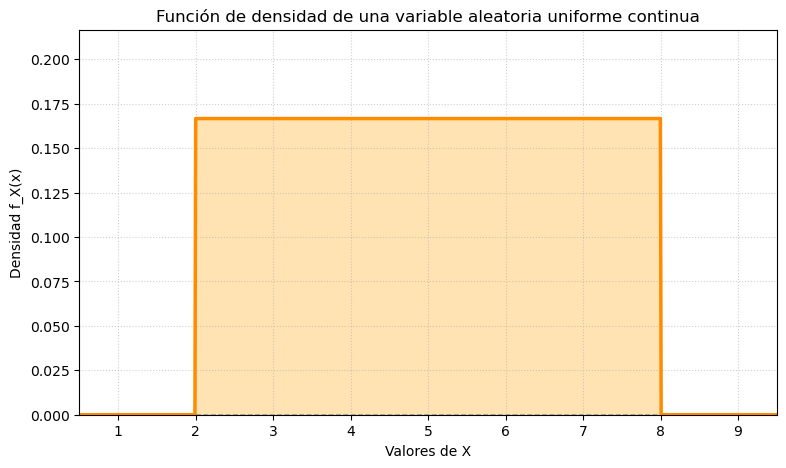

In [3]:
# Creamos un eje X extendido para ver cómo la densidad vale 0 fuera de [a, b]
x_eje = np.linspace(a - 2, b + 2, 1000)
f_densidad = uniform.pdf(x_eje, loc=u_loc, scale=u_scale)

plt.figure(figsize=(9, 5))

# Graficamos la línea de densidad continua
plt.plot(x_eje, f_densidad, color='darkorange', linewidth=2.5, label='f_X(x)')

# Sombreado del área (Representa que la masa de probabilidad es continua)
plt.fill_between(x_eje, f_densidad, color='orange', alpha=0.3, edgecolor='black', linestyle='--')

# Configuración formal de títulos y etiquetas de la gráfica
plt.title('Función de densidad de una variable aleatoria uniforme continua')
plt.xlabel('Valores de X')
plt.ylabel('Densidad f_X(x)')

# Ajustes de visualización en los ejes
plt.xlim(a - 1.5, b + 1.5)
plt.ylim(0, (1 / u_scale) + 0.05)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Variable aleatoria exponencial con parámetro $\lambda >0$

La distribución exponencial es una de las distribuciones continuas más utilizadas. A menudo se utiliza para modelar el tiempo transcurrido entre eventos.

Algunos ejemplos en los que podría utilizarse la distribución exponencial son:
* El tiempo transcurrido en un call center hasta recibir la primera llamada del día.
* El tiempo entre terremotos de una determinada magnitud.
* La cantidad de metros de alambre que produce una máquina hasta encontrar una falla en el alambre.

Se dice que la variable aleatoria $X$ tiene distribución exponencial de parámetro $\lambda>0$ si su función de densidad está dada por:
$$f_{X}(x)=\begin{cases}
\lambda e^{-\lambda x} & x>0\\
0 & \text{en otro caso}
\end{cases}$$

La esperanza y varianza son:
$$\mathbb{E}[X]= \frac{1}{\lambda}, \qquad Var(X)=\frac{1}{\lambda^2}$$

Notación. $X\sim Exp(\lambda).$


* **Propiedad de Falta de Memoria (Memorylessness):** Es la única distribución continua que no tiene memoria, lo que significa que la probabilidad de que ocurra un evento en el futuro es independiente del tiempo ya transcurrido:
$$\mathbb{P}(X > s + t \mid X > s) = \mathbb{P}(X > t) \quad \text{para } s, t \ge 0$$

#### **Nota importante para (`scipy.stats.expon`)**
En Python, la librería `scipy.stats.expon` parametriza la función utilizando el parámetro `scale` (escala), el cual representa la media de la distribución ($\frac{1}{\lambda}$), y no la tasa $\lambda$ directamente. Su estructura es:

`expon(loc, scale)`

Donde la correspondencia matemática exacta con la teoría es:
* `loc` = $0$ (por defecto, el punto de inicio del soporte).
* `scale` = $\frac{1}{\lambda}$ (el recíproco del parámetro de intensidad/tasa).

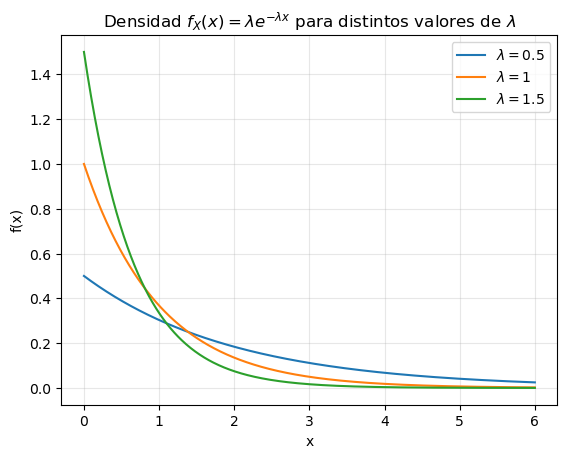

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 6, 500)
lambdas = [0.5, 1, 1.5]

for lam in lambdas:
    plt.plot(x, lam*np.exp(-lam*x), label=fr'$\lambda={lam}$')

plt.title(r'Densidad $f_X(x)=\lambda e^{-\lambda x}$ para distintos valores de $\lambda$')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Función de distribución (CDF)

Por definición, $F_X(x) = \mathbb{P}(X\le x) = \displaystyle\int_{-\infty}^{x} f_X(t)\,dt$. Para $X\sim Exp(\lambda)$ y $x>0$:

$$F_X(x) = \int_0^x \lambda e^{-\lambda t}\,dt = \left[-e^{-\lambda t}\right]_0^x = -e^{-\lambda x}-(-e^{0}) = 1-e^{-\lambda x}$$

Por lo tanto:

$$F_{X}(x)=\begin{cases}
1-e^{-\lambda x} & x\ge 0\\
0 & x<0
\end{cases}$$

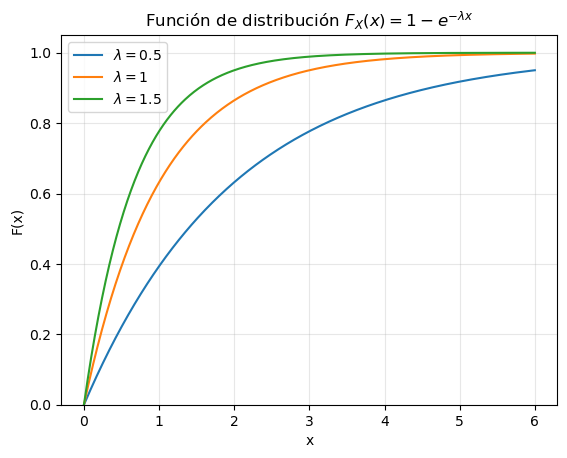

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 6, 500)
lambdas = [0.5, 1, 1.5]

for lam in lambdas:
    plt.plot(x, 1 - np.exp(-lam*x), label=fr'$\lambda={lam}$')

plt.title(r'Función de distribución $F_X(x)=1-e^{-\lambda x}$')
plt.xlabel('x'); plt.ylabel('F(x)'); plt.ylim(0, 1.05); plt.legend(); plt.grid(alpha=0.3)
plt.show()

De aquí se obtiene también la **función de supervivencia** (la cola de la distribución): 
$$\mathbb{P}(X>x) = 1-F_X(x) = e^{-\lambda x}$$

$\textbf{Propiedad de pérdida de memoria:}$
$$\mathbb{P}(X>t+s \mid X>t)=\mathbb{P}(X>s)=e^{-\lambda s}.$$

**¿Qué significa?** Si ya sabemos que el evento no ha ocurrido después de un tiempo $t$ (por ejemplo, un foco ya duró $t$ horas sin fallar), la probabilidad de esperar $s$ unidades de tiempo **más** es la misma que la probabilidad de esperar $s$ unidades desde el inicio. El proceso "no recuerda" cuánto tiempo ya transcurrió.

**Observación (parametrización alternativa).** A veces escriben la densidad exponencial en términos de su **media** $\mu = \dfrac{1}{\lambda}$ en lugar de la tasa $\lambda$:
$$f_{X}(x)=\begin{cases}
\dfrac{1}{\mu} e^{-x/\mu} & x>0\\[4pt]
0 & \text{en otro caso}
\end{cases}$$
Con esta parametrización:
$$\mathbb{E}[X]= \int_{0}^{\infty}x\, f_{X}(x)\,dx = \int_{0}^{\infty}x\,\frac{1}{\mu}e^{-x/\mu}\,dx = \mu$$
$$\text{Var}(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \int_{0}^{\infty}x^{2}\frac{1}{\mu}e^{-x/\mu}dx - \mu^{2} = 2\mu^2-\mu^2= \mu^{2}$$
Es **la misma** distribución de arriba; solo cambia el nombre del parámetro ($\mu = 1/\lambda$).

## Ejemplo

Consideremos la variable aleatoria $X$ como el tiempo (en minutos) entre la llegada de dos personas a la fila de una sucursal bancaria.

Adicionalmente, el banco ha determinado que solo el $10\%$ de las veces el tiempo que transcurre entre la llegada de una persona y otra es mayor a dos minutos.

Esto permite calcular el valor de $\lambda$, ya que
$$\mathbb{P}(X>2)=0.1$$
entonces
$$1-\mathbb{P}(X\le 2) = 1-F_{X}(2) = 0.1$$

Notemos que si $X\sim Exp(\lambda)$, entonces $F_{X}(x) = 1-e^{-\lambda x}$.

Por lo que $F_{X}(2)= 1-e^{-2\lambda} =0.9$, entonces $e^{-2\lambda}=0.1$. Por lo tanto
$$-2\lambda=\ln(0.1) \;\Rightarrow\; \lambda=\frac{-\ln(0.1)}{2}\approx 1.15$$

Por lo tanto $X\sim Exp(1.15)$. (Equivalentemente, el tiempo *promedio* entre llegadas es $1/\lambda \approx 0.87$ minutos — ese $0.87$ es la media, no $\lambda$.)

Ahora queremos calcular la probabilidad de que entre la llegada de una persona y otra transcurra por lo menos un minuto, lo cual puede calcularse de dos formas:

$$\mathbb{P}(X>1) = \int_{1}^{\infty}f_{X}(x)\,dx = \int_{1}^{\infty}1.15\,e^{-1.15x}\,dx = e^{-1.15}\approx 0.32$$

$$\mathbb{P}(X>1) = 1-\mathbb{P}(X\le 1) = 1-F_X(1) = 1-\left(1-e^{-1.15}\right)=e^{-1.15}\approx 0.32$$

Ambos métodos coinciden, como debe ser.

In [9]:
import numpy as np
from scipy.stats import expon

# lambda obtenido a partir de P(X>2) = 0.1
lam = -np.log(0.1) / 2
print("lambda =", round(lam, 4))   

rv = expon(scale=1/lam)  # scale = 1/lambda, NO lambda
print("P(X>1) =", round(rv.sf(1), 4))   # sf es la funcion de supervivencia

lambda = 1.1513
P(X>1) = 0.3162


## Ejercicios adicionales

**Ejercicio 1.** El tiempo (en minutos) entre llegadas de clientes a una caja registradora se modela como $X\sim Exp(\lambda)$, con un tiempo promedio entre llegadas de 3 minutos.
a) Encuentra $\lambda$.
b) Calcula $\mathbb{P}(X<2)$.
c) Calcula $\mathbb{P}(X>4)$.
d) Calcula $\mathbb{P}(2<X<6)$.

**Ejercicio 2 (pérdida de memoria).** La duración de un foco (en horas) es $X\sim Exp(\lambda)$ con duración promedio de 1000 horas. Si el foco ya ha funcionado 500 horas sin fallar, ¿cuál es la probabilidad de que dure al menos 500 horas más? Resuelve usando la propiedad de pérdida de memoria y comprueba que coincide con $\mathbb{P}(X>500)$ calculada "desde cero".


**Ejercicio 3 (proceso de Poisson).** Los terremotos de magnitud $\geq 5$ en una región ocurren, en promedio, 2 veces al año, y el tiempo entre ellos se modela como exponencial. ¿Cuál es la probabilidad de que el próximo terremoto de esa magnitud ocurra dentro de los siguientes 3 meses?

$\color{red}{\text{Ejercicio 2.}}$ Calcular las probabilidades con Scipy

In [9]:
from scipy.stats import expon
import numpy as np

#  Definimos los parámetros 
lam = 0.5  # Ejemplo: llegan en promedio 0.5 clientes por minuto
escala = 1 / lam  # scale = 1/lambda para SciPy

#  Generamos los puntos en el eje x
x = np.linspace(0, 10, 1000)

# calculamos la PDF y CDF usando 'expon' directamente
pdf_expon = expon.pdf(x, loc=0, scale=escala)
cdf_expon = expon.cdf(x, loc=0, scale=escala)

print("="*45)
print("     RESULTADOS DE LA DISTRIBUCIÓN EXPONENCIAL     ")
print("="*45)
print(f"Parámetro de tasa (lambda):       {lam}")
print(f"Parámetro de escala (1/lambda):   {escala} (Media teórica)")
print(f"Rango del eje x generado:         Desde {x[0]} hasta {x[-1]}")
print(f"Número total de puntos evaluados: {len(x)}")

     RESULTADOS DE LA DISTRIBUCIÓN EXPONENCIAL     
Parámetro de tasa (lambda):       0.5
Parámetro de escala (1/lambda):   2.0 (Media teórica)
Rango del eje x generado:         Desde 0.0 hasta 10.0
Número total de puntos evaluados: 1000


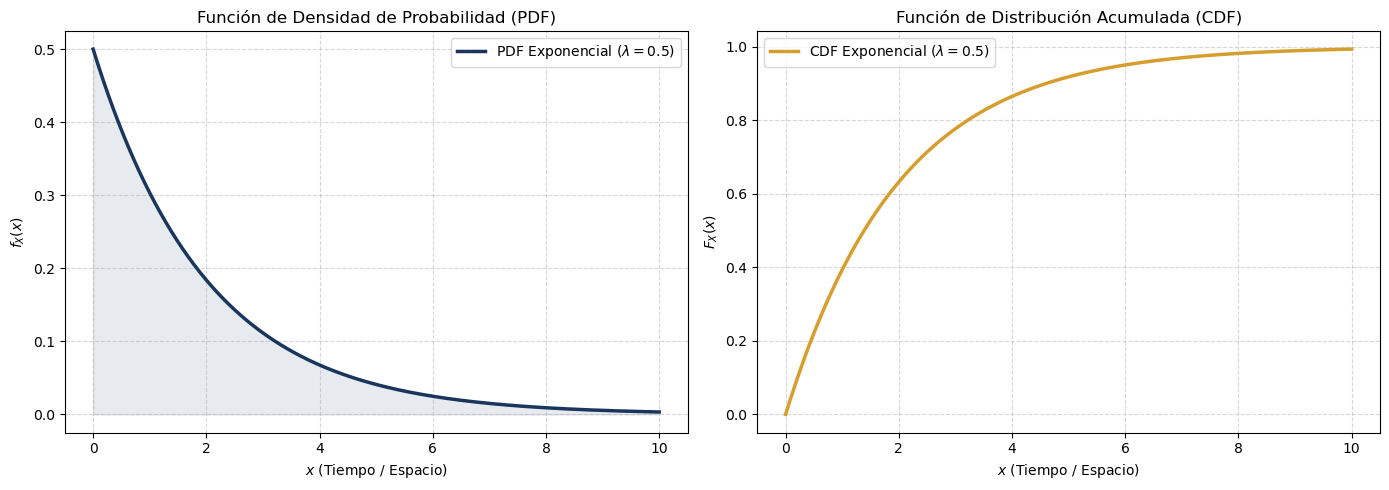

In [10]:
import matplotlib.pyplot as plt

# Configuramos el tamaño de la figura (dos gráficas paralelas)
plt.figure(figsize=(14, 5))

# 1. Gráfica de la Función de Densidad (PDF)
plt.subplot(1, 2, 1)
plt.plot(x, pdf_expon, label=f'PDF Exponencial ($\lambda={lam}$)', color='#1A365D', lw=2.5)
plt.fill_between(x, pdf_expon, color='#1A365D', alpha=0.1)
plt.title('Función de Densidad de Probabilidad (PDF)')
plt.xlabel('$x$ (Tiempo / Espacio)')
plt.ylabel('$f_X(x)$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 2. Gráfica de la Función Acumulada (CDF)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_expon, label=f'CDF Exponencial ($\lambda={lam}$)', color='#D69E2E', lw=2.5)
plt.title('Función de Distribución Acumulada (CDF)')
plt.xlabel('$x$ (Tiempo / Espacio)')
plt.ylabel('$F_X(x)$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Ajustamos los espacios e imprimimos en pantalla
plt.tight_layout()
plt.show()

# Variable aleatoria normal con parámetros media $\mu$ y varianza $\sigma^{2}$.

La distribución normal es una de las más importantes y de mayor uso tanto en la teoría de la probabilidad, como en la teoría estadística.

También llamada distribución gaussiana, en honor a Gauss, a quien se considera el padre de ésta distribución.

La importancia de la distribución normal, radica en el famoso Teorema central del límite. Fue descubierta por De Moivre en 1733 como un límite de la distribución binomial.


La importancia de esta distribución radica en que permite modelar numerosos fenómenos naturales, sociales y psicológicos, por ejemplo:
* Estatura
* Efectos de un fármaco
* Consumo de cierto producto por un grupo de individuos
* Coeficiente intelectual
* Nivel de ruido en telecomunicaciones
* Errores cometidos al medir ciertas magnitudes

Además, esta distribución juega un papel de suma importancia en la inferencia estadística.

Se dice que la variable aleatoria $X$ tiene distribución normal de parámetros $\mu$ y $\sigma^{2}$, donde $\mu,\sigma\in\mathbb{R}$ y $\sigma>0$, si su función de densidad está dada por:
$$f_{X}(x)=\begin{cases}
	\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-\mu)^{2}}{2\sigma^{2}}} &\quad \text{si }  x \in\mathbb{R} \\
	\qquad 0 &\quad \text{e.o.c}  
\end{cases}$$

**Notación.** $X\sim N(\mu,\sigma^{2})$


Tal curva (**la campana de Gauss-Bell**) es una función que depende de los parámetros $\mu$ y $\sigma^{2}$.


**Observación:** El parámetro $\mu$ se llama *media* y el  parámetro $\sigma^{2}$ se llama *varianza*.

La función de densidad definida anteriormente es efecto función de densidad, ya que
$$\int_{\mathbb{R}}f_{X}(x)dx = \int_{\mathbb{R}}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-m)^{2}}{2\sigma^{2}}}  = 1 $$

Variable aleatoria normal con parámetros  0  y  1 .
La ley de $Z\sim N(0,1)$ está dada por la función de densidad
$$
f_{Z}(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}},
$$
para $z\in \mathbb{R}$.

Sabemos que:
* La varianza es usada como una medida para comparar la dispersión en dos o más conjuntos de observaciones.
* Una desviación estándar pequeña indica que los valores de la variable aleatoria se encuentran cercanos a la media.
* Una desviación estándar grande indica que los valores de la variable aleatoria se dispersan mucho con respecto a la media.

La función de distribución de una variable aleatoria $X\sim N(\mu,\sigma^{2})$ está dada por:
$$F_{X}(x) = \int_{-\infty}^{x}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(y-\mu)^{2}}{2\sigma^{2}}}dy$$

Esta nos proporciona la probabilidad de que $X$ tome calores menores o iguales a un valor específico $x$, y corresponde al área bajo la curva en el intervalo $(-\infty,x]$:

No es sencillo calcular $F_{X}(x)$, pero cualquier v.a. gaussiana puede transformarse a una v.a. estandarizada. Existen tablas para esta v.a., lo cual hace los cálculos más fáciles.

**Proposición**  Sea $X\sim N(\mu,\sigma^{2})$, entonces
$$Z=\frac{X-\mu}{\sigma}$$
tiene una distribución gaussiana con media $0$ y varianza $1$, es decir, $Z\sim N(0,1)$.


**Demostración** 	Primero vamos a calcular la función de distribución de $Z$:
$$F_{Z}(z):=\mathbb{P}(Z\le z) = \mathbb{P}\left(\frac{X-\mu}{\sigma}\le z\right) = \mathbb{P}(X\le \sigma z + \mu) := F_{X}(\sigma z + \mu)$$
Entonces, la función de densidad de $Z$ esta dada por:
$$f_{Z}(z) = \frac{dF_{Z}(z)}{dz} = \frac{dF_{X}(\sigma z + \mu)}{dz} = \sigma f_{X}(\mu+\sigma z) = \frac{e^{-z^{2}/2}}{\sqrt{2\pi}}$$

Decimos que $X$ tiene distribución gaussiana estándar (normal estándar), $X\sim N(0,1)$, si su función de densidad esta dada por:
$$f_{X}(x)=\begin{cases}
	\frac{e^{-x^{2}/2}}{\sqrt{2\pi}} &\quad \text{si }  x \in\mathbb{R} \\
	\quad 0 &\quad \text{e.o.c}  
\end{cases}$$

Podemos calcular cualquier probabilidad de la forma
$$\mathbb{P}(a<X<b)$$
de la siguiente manera: para $z\ge 0$, definimos
$$\Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{0}^{z}e^{-x^{2}/2}dx.$$



- De acuerdo con nuestras notas de clase, las funciones generadoras nos permiten identificar distribuciones de forma única y facilitar el cálculo de momentos. 

- Para una variable aleatoria $X \sim N(\mu, \sigma^2)$, sus funciones generadoras están dadas por:

* **Función Generadora de Momentos (FGM):**
$$M_X(t) = e^{\mu t + \frac{1}{2}\sigma^2 t^2}$$

* **Función Característica (FC):** Recuerda que esta siempre existe y maneja variables complejas ($i = \sqrt{-1}$):
$$\varphi_X(t) = \mathbb{E}[e^{itX}] = e^{i\mu t - \frac{1}{2}\sigma^2 t^2}$$

#### **Propiedad Reproductiva de la Normal (Suma de Independientes)**
Citando la importancia matemática de tus apuntes sobre la suma de variables independientes ($\varphi_{X+Y}(t) = \varphi_X(t)\varphi_Y(t)$): si tenemos $n$ variables normales independientes tales que $X_j \sim N(\mu_j, \sigma_j^2)$, su combinación lineal también es normal. Esto es la base fundamental del **Teorema del Límite Central** usado por Lyapunov en 1904.


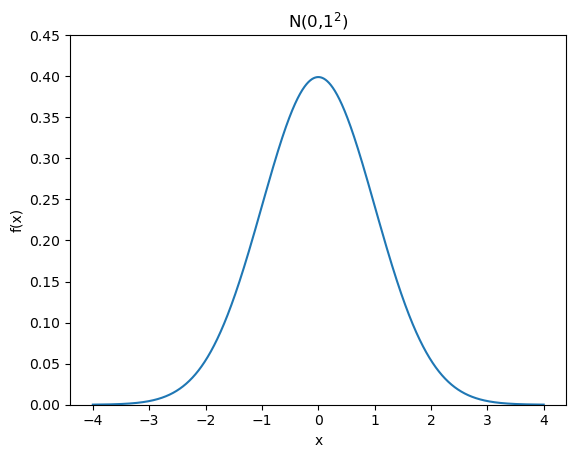

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
fig, ax = plt.subplots()
x= np.arange(-4,4,0.001) #generar valores de x
ax.set_title('N(0,$1^2$)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.plot(x, norm.pdf(x))
ax.set_ylim(0,0.45)
plt.show()

Propiedades de la función de densidad de probabilidades de una distribución normal estándar:

1. Es positiva: $f(x)\geq 0$ para todo $x$ real.
2. Es continua y derivable en todas partes.
3. Es simétrica alrededor de $\mu$.
4. Conforme $x$ toma valores muy grandes de manera positiva y negativa, la función decrece hacia cero muy rápidamente.
5. Tiene un máximo global.
6. El área total bajo la curva es igual a $1$.

Veamos el comportamiento de la función conforme se cambia la varianza.

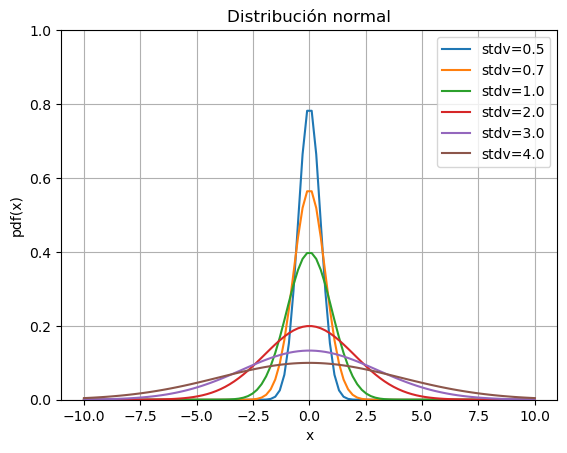

In [12]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100)
stdvs = [0.5, 0.7, 1.0, 2.0, 3.0, 4.0]
for s in stdvs:
    ax.plot(x, norm.pdf(x,scale=s), label='stdv=%.1f' % s)

ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.set_title('Distribución normal')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,1)
ax.grid(True)

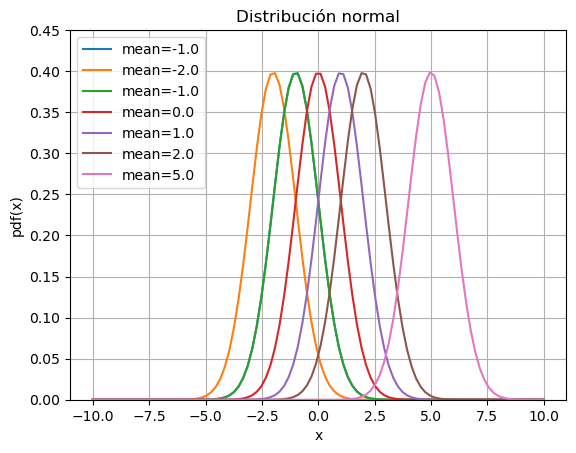

In [13]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100)
means = [-1.0,-2.0, -1.0, 0.0, 1.0, 2.0, 5.0]
for mean in means:
    ax.plot(x, norm.pdf(x,loc=mean), label='mean=%.1f' % mean)

ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.set_title('Distribución normal')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,0.45)
ax.grid(True)

### **Ejemplo de Modelado de Costos de Reclamación**

En la práctica actuarial, los costos de ciertos tipos de siniestros automotrices se pueden modelar mediante una distribución normal cuando se analiza una cartera grande. 

Supongamos que el costo de una reclamación por choque menor sigue una distribución normal con una media de $\mu = \$25,000$ pesos y una desviación estándar de $\sigma = \$4,000$ pesos ($X \sim N(25000, 4000^2)$).

Calcularemos e imprimiremos con Python:
1. La probabilidad de que una reclamación sea de **menos de \$20,000 pesos**.
2. La probabilidad de que una reclamación cueste **entre \$22,000 y\  \$28,000 pesos**.
3. El **VaR (Value at Risk)** al 95%, es decir, el monto de reclamación que solo se supera el 5% de las veces (Percentil 95).

In [11]:
from scipy.stats import norm
import numpy as np

# Definimos los parámetros de nuestra v.a. normal
mu = 25000
sigma = 4000

# 1. P(X < 20000) - Usamos la CDF acumulada
prob_menor_20 = norm.cdf(20000, loc=mu, scale=sigma)

# 2. P(22000 <= X <= 28000) - Diferencia de CDFs
prob_entre = norm.cdf(28000, loc=mu, scale=sigma) - norm.cdf(22000, loc=mu, scale=sigma)

# 3. Percentil 95 (Value at Risk) - Usamos la función cuantil (ppf)
var_95 = norm.ppf(0.95, loc=mu, scale=sigma)

print("="*50)
print("     ANÁLISIS ACTUARIAL: DISTRIBUCIÓN NORMAL     ")
print("="*50)
print(f"1. P(Costo < $20,000):        {prob_menor_20:.4f} ({prob_menor_20*100:.2f}%)")
print(f"2. P($22,000 <= X <= $28,000): {prob_entre:.4f} ({prob_entre*100:.2f}%)")
print(f"3. Umbral de Pérdida (Monto Máximo al 95%): ${var_95:,.2f} pesos")
print("="*50)

     ANÁLISIS ACTUARIAL: DISTRIBUCIÓN NORMAL     
1. P(Costo < $20,000):        0.1056 (10.56%)
2. P($22,000 <= X <= $28,000): 0.5467 (54.67%)
3. Umbral de Pérdida (Monto Máximo al 95%): $31,579.41 pesos


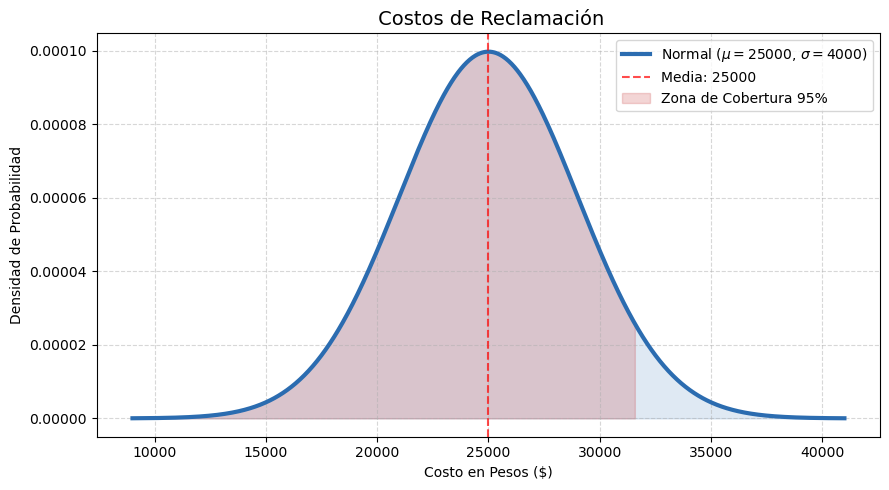

In [13]:
import matplotlib.pyplot as plt

# Generamos un rango de 4 desviaciones estándar alrededor de la media para la gráfica
x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf_norm = norm.pdf(x_norm, loc=mu, scale=sigma)

plt.figure(figsize=(9, 5))

# Graficamos la curva principal
plt.plot(x_norm, pdf_norm, color='#2B6CB0', lw=3, label=f'Normal ($\mu={mu}$, $\sigma={sigma}$)')
plt.fill_between(x_norm, pdf_norm, color='#2B6CB0', alpha=0.15)

# Línea vertical para la media
plt.axvline(mu, color='red', linestyle='--', alpha=0.7, label=f'Media: {mu}')

# Sombreado del VaR 95% como extra visual
x_var = np.linspace(mu - 4*sigma, var_95, 1000)
plt.fill_between(x_var, norm.pdf(x_var, loc=mu, scale=sigma), color='#C53030', alpha=0.2, label='Zona de Cobertura 95%')

plt.title(' Costos de Reclamación', fontsize=14)
plt.xlabel('Costo en Pesos ($)')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Función de distribución acumulativa de una normal $N(\mu,\sigma^2)$.

Gracias a las propiedades anteriores, es posible calcular áreas delimitadas de la función $f$. Si $a$ y $b$ son reales cualesquiera, denotaremos por
$$P(a\leq X\leq b),$$
la probabilidad de que $X$ esté en el intervalo $[a,b]$, al área bajo la curva de $f(x)$ sobre el intervalo $[a,b]$.

También, $P(X\leq x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(-\infty,x)$ y $P(X>x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(x, \infty)$.

A la probabilidad $\text{cdf}(x):=P(X\leq x)$ se llama la distribución acumulativa (hasta el valor $x$) de $f(x)$.

Con la notación anterior,
$$P(a\leq X\leq b)=\text{cdf}(b)-\text{cdf}(a)$$
y
$$\text{sf}(a):=P(X>a)=1-\text{cdf}(a).$$
    

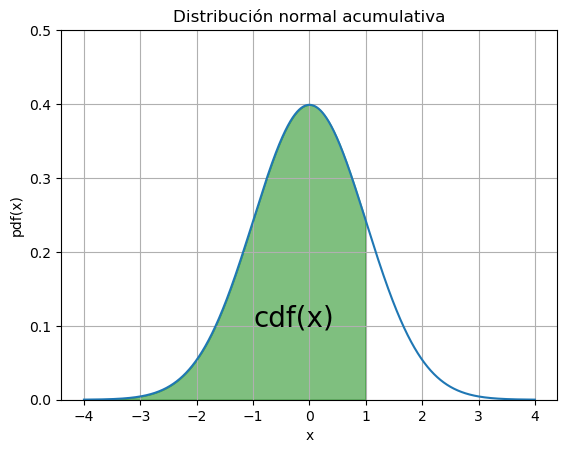

In [14]:
from scipy.stats import norm
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-4,4,0.001)
ax.plot(x, norm.pdf(x))
ax.set_title("Distribución normal acumulativa")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
# for fill_between
px=np.arange(-4,1,0.01)
ax.set_ylim(0,0.5)
ax.fill_between(px,norm.pdf(px),alpha=0.5, color='g')
# for text
ax.text(-1,0.1,"cdf(x)", fontsize=20)
plt.show()

### Cálculo de probabilidades de una distribución normal

Calculemos $\text{cdf}(2)=\mathbb{P}(X<2)$ cuando $X\sim N(3,2^2)$.

$$Z = \frac{X-\mu}{\sqrt{\sigma^2}} \sim N(0,1)$$

In [15]:
norm.cdf(x=2, loc=3, scale=2) #v.a. con media=3 y st=2

np.float64(0.3085375387259869)

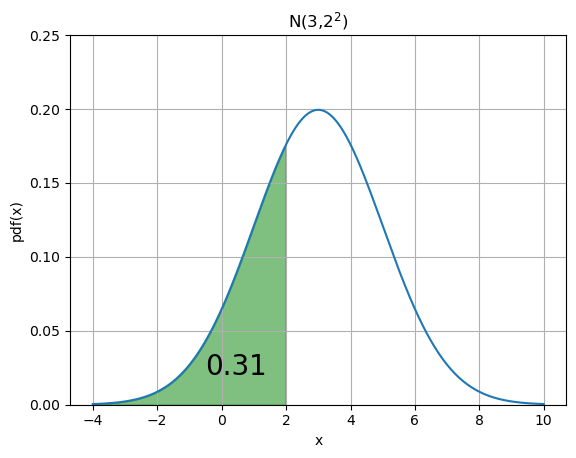

In [16]:
from scipy.stats import norm
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-4,10,0.001)
ax.plot(x, norm.pdf(x,loc=3,scale=2))
ax.set_title("N(3,$2^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
# for fill_between
px=np.arange(-4,2,0.01)
ax.set_ylim(0,0.25)
ax.fill_between(px,norm.pdf(px,loc=3,scale=2),alpha=0.5, color='g')
# for text
ax.text(-0.5,0.02,round(norm.cdf(x=2, loc=3, scale=2),2), fontsize=20)
plt.show()

In [17]:
s=np.sqrt(2)
norm(1, s).cdf(2) - norm(1,s).cdf(0.5)

np.float64(0.3984131339906417)

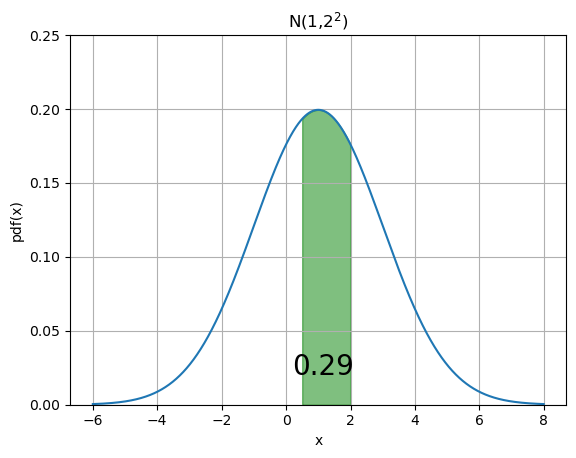

In [18]:
fig, ax = plt.subplots()
x= np.arange(-6,8,0.001)
ax.plot(x, norm.pdf(x,loc=1,scale=2))
ax.set_title("N(1,$2^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(0.5,2,0.01)
ax.set_ylim(0,0.25)
ax.fill_between(px,norm.pdf(px,loc=1,scale=2),alpha=0.5, color='g')
pro=norm(1, 2).cdf(2) - norm(1,2).cdf(0.5)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

**Ejemplo importante** Si $Z\sim N(0,1)$, encuentra $\mathbb{P}(-1.93 < Z < 1.93)$. La probabilidad buscada es:


In [19]:
norm(0,1).cdf(1.93)-norm(0,1).cdf(-1.93)

np.float64(0.9463931622458901)

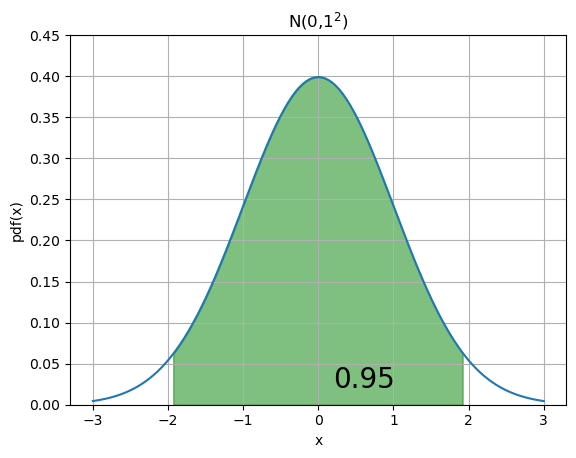

In [20]:
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-3,3,0.001)
ax.plot(x, norm.pdf(x,loc=0,scale=1))
ax.set_title("N(0,$1^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(-1.93,1.93,0.01)
ax.set_ylim(0,0.45)
ax.fill_between(px,norm.pdf(px,loc=0,scale=1),alpha=0.5, color='g')
pro=norm(0, 1).cdf(1.93) - norm(0,1).cdf(-1.93)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

In [16]:
norm(0,1).cdf(1) - norm(0,1).cdf(-1)

np.float64(0.6826894921370859)

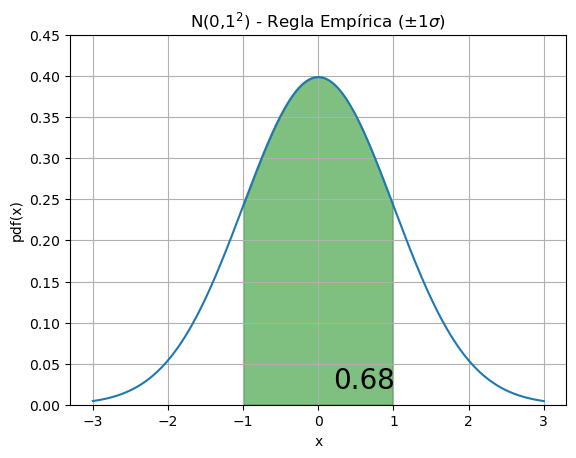

In [17]:
fig, ax = plt.subplots()
# for distribution curve
x = np.arange(-3, 3, 0.001)
ax.plot(x, norm.pdf(x, loc=0, scale=1))
ax.set_title("N(0,$1^2$) - Regla Empírica ($\pm 1 \sigma$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)

# Definimos el nuevo intervalo simétrico para rellenar
px = np.arange(-1, 1, 0.01)
ax.set_ylim(0, 0.45)
ax.fill_between(px, norm.pdf(px, loc=0, scale=1), alpha=0.5, color='g')

# Calculamos el área exacta para este intervalo
pro = norm(0,1).cdf(1) - norm(0,1).cdf(-1)
ax.text(0.2, 0.02, round(pro, 2), fontsize=20)

plt.show()

### Cálculo de probabilidades:
$\mathbb{P}(0<Z<b)$: Queremos calcular $\mathbb{P}(0<Z<0.43)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(0<Z<0.43) = 0.1664$

$\mathbb{P}(-b<Z<b)$: Queremos calcular $\mathbb{P}(-0.16<Z<0.16)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha:  $\mathbb{P}(-0.16<Z<0.16) = \mathbb{P}(-0.16<Z<0)+\mathbb{P} (0<Z<0.16) = \mathbb{P}(0<Z<0.16)+\mathbb{P}(0<Z<0.16) = 2\mathbb{P}(0<Z<0.16) = 2(0.0636) = 0.1272$

$\mathbb{P}(Z<-b)$: Queremos calcular $\mathbb{P}(Z<-1.94)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(Z<-1.94) = \mathbb{P}(Z<0)+\mathbb{P}(-1.94<Z<0) = \mathbb{P}(Z<0) + \mathbb{P}(0<Z<1.94) = 0.5 - 0.4738 = 0.0262$

$\mathbb{P}(Z>-b)$: Queremos calcular $(Z>-0.07)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(Z>-0.07) = \mathbb{P}(-0.07<Z<0) + \mathbb{P}(Z>0) = \mathbb{P}(0<Z<0.07) + \mathbb{P}(Z>0) = 0.0279 + 0.5 = 0.5279$

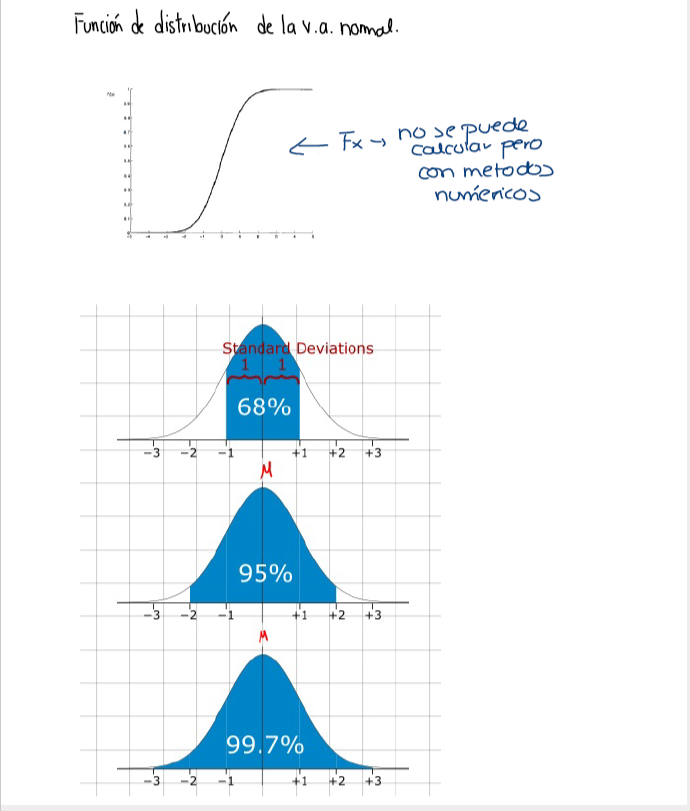

## Variable aleatoria Gamma con parámetros $\alpha$ y $\lambda$.

 La distribución gamma se obtiene al considerar el tiempo que transcurre entre cierto número de ocurrencias de eventos que ocurren aleatoriamente en el tiempo

La función gamma $\Gamma:(0,\infty)\to \mathbb{R}$ está definida como
	$$\Gamma(\alpha)=\int_{0}^{\infty}t^{\alpha-1}e^{-t}dt.$$



*Propiedades de la función gamma*.
- $\Gamma(\alpha)<\infty$ para cualquier $\alpha>0$.
- $\Gamma(\alpha+1)=\alpha\Gamma(\alpha)$.
- Si $n\geq 1$ $\Gamma(n)=(n-1)!$
- $\Gamma\left(\frac{1}{2} \right)=\sqrt{\pi}$.



 Si $\alpha$ y $\lambda$ son reales positivos, decimos que una variable aleatoria $X$ tiene distribución gamma con parámetros $\alpha$ y $\lambda$ si tiene por función de densidad:
	$$\displaystyle f_{X}(x)=\begin{cases}
	\displaystyle \frac{\lambda^{\alpha}x^{\alpha-1}e^{-\lambda x} }{\Gamma(\alpha)} & x>0\\
	0 & \text{en otro caso}
	\end{cases}$$
En esta caso, escribimos la información anterior como $X\sim \Gamma(\alpha,\lambda) $


Ejemplo 1. Una computadora cuántica cuenta con un tipo de aparato de medición, el cual tiene un tiempo de vida que se distribuye exponencialmente, de tal manera que su tiempo promedio de vida es de  $1000$ horas. Si se utilizan $10$ de estos aparatos en forma consecutiva, uno de ellos después de que el anterior ya no funciona. ¿Cuál es la probabilidad de que alguno de los aparatos estará funcionando después de $10,000$ horas?


**Solución.**
Sea $X$ el tiempo total de vida de los $5$ aparatos, usados, como se indica, uno después del otro. Entonces $X\sim \Gamma(10, 0.001)$. Así,
$$\mathbb{P}(X>10000)=\int_{10000}^{\infty}\frac{(0.001)^{10}}{9!}x^{9}e^{-0.001x}dx=0.4579.$$

Ejemplo 2.  Consideremos un call center donde los tiempos entre llamadas son independientes y se distribuyen exponencialmente con una media de 3 minutos. Supongamos que queremos encontrar la probabilidad de que transcurran más de 30 minutos antes de recibir 10 llamadas.


**Solución.**
Sea $X$ el tiempo total para recibir $10$ llamadas. Dado que el tiempo medio entre llamadas es de $3$ minutos. Entonces $X \sim \Gamma(10, \frac{1}{3})$. Así
$$P(X > 30) = \int_{30}^{\infty} \frac{\left(\frac{1}{3}\right)^{10} x^{9} e^{-\frac{x}{3}}}{9!} \, dx = 0.45793.$$

**Nota.** Si $X\sim N(0,1)$, entonces $X^{2}\sim \Gamma\left(\frac{1}{2}, \frac{1}{2} \right)$.
En efecto, Para $z>0$, se tiene:
	$$F_{X^{2}}(z)=\mathbb{P}(X^2\leq z)=\mathbb{P}(-\sqrt{z}\leq X\leq \sqrt{z})=F_{X}(\sqrt{z})-F_{X}(-\sqrt{z}).$$
Por lo tanto,
$$f_{X^2}(z)=\frac{d F_{X^{2}}(z)}{dz}=\frac{1}{2\sqrt{z}}f_{X}(\sqrt{z})+\frac{1}{2\sqrt{z}}f_{X}(-\sqrt{z})=\frac{1}{\sqrt{z}}f_{X}(z).$$
Ahora,
$$f_{X}(\sqrt{z})=\frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}z}.$$


### Esperanza y Varianza

La esperanza, $\text{E}[X]$ para una variable aleatoria $X\sim Γ(\alpha, \lambda)$ es:

$$
\mathbb{E}(X) = \frac{\alpha}{\lambda}
$$
y su varianza es:
$$
\text{Var}(X) = \frac{\alpha}{\lambda^2}
$$



La distribución gamma es esencial en varios campos por su capacidad para modelar tiempos de espera y eventos con tasas constantes. Sus aplicaciones incluyen:

  * $\textbf{Teoría de colas y procesos estocásticos:}$ Modela el tiempo de espera hasta el k-ésimo evento.
  * $\textbf{Confiabilidad y análisis de supervivencia:}$ Utilizada para tiempos de fallo y eventos críticos en medicina.
  * $\textbf{Hidrología y meteorología:}$ Aplica en la modelación de precipitaciones acumuladas y tamaños de gotas.
  * $\textbf{Procesamiento de imágenes y señales:}$ En el ajuste de modelos a datos de intensidades.
  * $\textbf{Finanzas:}$ Para rendimientos de activos que no siguen distribuciones normales.
  * $\textbf{Biología y ecología:}$ Para tasas de crecimiento y tiempos entre eventos biológicos.
  * $\textbf{Física:}$ Describe tiempos de decaimiento y distribuciones de energía.


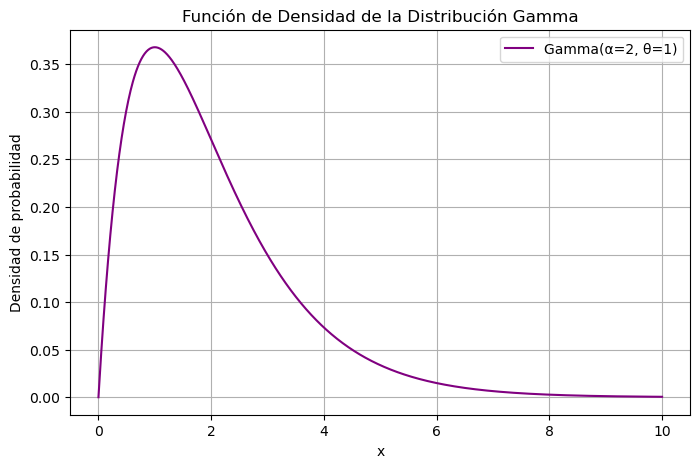

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Parámetros de la distribución Gamma
shape_param = 2  # Parámetro de forma (k o α)
scale_param = 1  # Parámetro de escala (θ)

# Generar valores de x
x = np.linspace(0, 10, 1000)

# Calcular la PDF de la distribución Gamma
gamma_pdf = gamma.pdf(x, a=shape_param, scale=scale_param)

# Graficar la PDF de la distribución Gamma
plt.figure(figsize=(8, 5))
plt.plot(x, gamma_pdf, label=f'Gamma(α={shape_param}, θ={scale_param})', color='purple')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad de la Distribución Gamma')
plt.grid(True)
plt.legend()
plt.show()

- Si $\alpha = 1$, $\lambda > 0 \Rightarrow$ v.a. exponencial.

- Si $\lambda = \frac{1}{2}$, $\alpha = \frac{k}{2}$, $k \in \mathbb{Z}^{+} \Rightarrow$ ji-cuadrada.

- Si $\lambda > 1$ y $\alpha > 1 \Rightarrow$ Erlang $\Rightarrow$ aplicaciones.

**Ejemplo** Sea $X \sim \mathcal{N}(0,1)$. Demostrar que $ X^2 $ tiene una distribución gamma.

**Solución:** Para $z \geq 0$, se tiene que:

$$
\begin{align*}
F_{X^2}(z) &= P(X^2 \leq z) = P(-\sqrt{z} \leq X \leq \sqrt{z}) \\
&= F_X(\sqrt{z}) - F_X(-\sqrt{z}) \\
\end{align*}
$$
Derivando, obtenemos la función de densidad:

$$ f_{X^2}(z) = \frac{d}{dz} F_{X^2}(z) = \frac{1}{2\sqrt{z}} f_X(\sqrt{z}) + \frac{1}{2\sqrt{z}} f_X(-\sqrt{z}) $$

Como la densidad de $X$ es simétrica, se tiene que 

$$ f_{X^2}(z) = \frac{1}{\sqrt{2\pi}} e^{-z/2} \frac{1}{2\sqrt{z}} = \frac{(1/2)^{1/2} z^{-1/2} e^{-z/2}}{\Gamma(1/2)}  \sim Gamma\left(\frac{1}{2}, \frac{1}{2}\right) $$

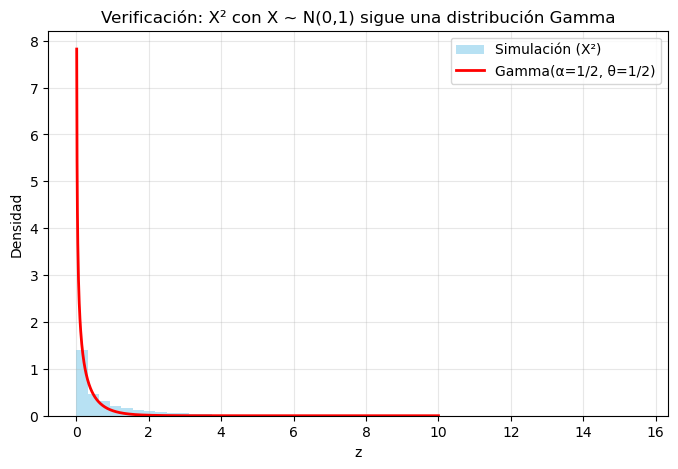

In [19]:
from scipy.stats import norm, gamma
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulamos 10,000 valores de X ~ N(0,1) y elevamos al cuadrado
x_simulado = np.random.normal(0, 1, 10000)
z_simulado = x_simulado**2

# 2. Definimos los parámetros de la Gamma resultante (según tu demostración)
alpha_gamma = 0.5
theta_gamma = 0.5

# 3. Graficamos el histograma de los datos simulados vs la densidad teórica Gamma
plt.figure(figsize=(8, 5))
plt.hist(z_simulado, bins=50, density=True, alpha=0.6, color='skyblue', label='Simulación (X²)')

# Graficamos la PDF de la Gamma teórica para comparar
x_teo = np.linspace(0.01, 10, 1000)
pdf_teo = gamma.pdf(x_teo, a=alpha_gamma, scale=theta_gamma)
plt.plot(x_teo, pdf_teo, color='red', lw=2, label=f'Gamma(α=1/2, θ=1/2)')

plt.title('Verificación: X² con X ~ N(0,1) sigue una distribución Gamma')
plt.xlabel('z')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

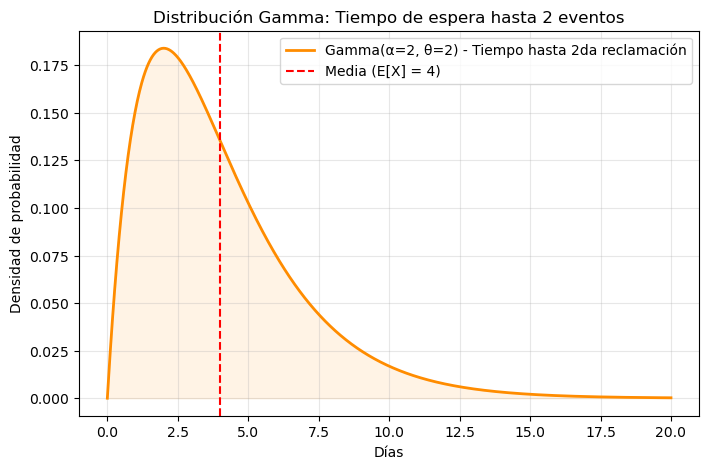

In [20]:
from scipy.stats import gamma
import numpy as np
import matplotlib.pyplot as plt

# Parámetros: Tiempo hasta la 2da reclamación (alpha=2), media de 2 días por evento (theta=2)
alpha_forma = 2 
theta_escala = 2 

# Generar valores
x = np.linspace(0, 20, 1000)

# Calcular PDF
gamma_pdf = gamma.pdf(x, a=alpha_forma, scale=theta_escala)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(x, gamma_pdf, label=f'Gamma(α={alpha_forma}, θ={theta_escala}) - Tiempo hasta 2da reclamación', color='darkorange', lw=2)
plt.fill_between(x, gamma_pdf, color='darkorange', alpha=0.1)

# Añadir una línea para la media teórica (E[X] = alpha * theta = 4)
plt.axvline(alpha_forma * theta_escala, color='red', linestyle='--', label='Media (E[X] = 4)')

plt.title('Distribución Gamma: Tiempo de espera hasta 2 eventos')
plt.xlabel('Días')
plt.ylabel('Densidad de probabilidad')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Variable aleatoria Beta con parámetros $\alpha$ y $\beta$.


La distribución beta es una familia de distribuciones de probabilidad continua definida en el intervalo [0, 1]. Es particularmente útil para modelar variables que representan proporciones y porcentajes.

La función beta, $B(\alpha, \beta)$, se define como:

$$
B(\alpha, \beta) = \int_0^1 t^{\alpha-1}(1-t)^{\beta-1} dt = \frac{\Gamma(\alpha) \Gamma(\beta)}{\Gamma(\alpha + \beta)}
$$

La función de densidad de probabilidad de la distribución beta se expresa como:

$$
f_X(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)},
$$
con $x\in (0,1)$.

**Notación.** $X\sim \text{Beta}(\alpha, \beta)$.



### Esperanza y Varianza
Si $X\sim \text{Beta}(\alpha, \beta)$, entonces
  $$\mathbb{E}[X] = \frac{\alpha}{\alpha + \beta}$$
y
  $$\text{Var}(X) = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}.$$


### **Propiedades**

* **Flexibilidad de forma:** Dependiendo de los valores de $\alpha$ y $\beta$, la distribución puede ser simétrica, sesgada a la izquierda, sesgada a la derecha, o incluso tener forma de "U" (cuando $\alpha, \beta < 1$). 

* **Relación Bayesiana:** En estadística bayesiana, la Beta es la "distribución a priori conjugada" para el parámetro de éxito de una distribución Bernoulli o Binomial. Esto significa que si partes de una creencia Beta sobre una probabilidad y observas datos, tu creencia actualizada sigue siendo una distribución Beta.

* **Interpretación Actuarial:** Es ideal para modelar tasas de recuperación de cartera (*recovery rates*) o tasas de siniestralidad esperadas, donde los valores siempre están contenidos entre $0$ y $1$ (o $0\%$ y $100\%$).


**Ejemplo.** Supongamos que un análisis sugiere que una nueva inversión tiene una alta probabilidad de éxito. Usando una distribución beta con $\alpha = 5$ y $\beta = 1$, entonces:

$$
f_{X}(x) = 5x^4, \quad \mathbb{E}[X] = \frac{5}{6}, \quad \text{Var}(X) = \frac{5}{252}
$$


**Aplicaciones en la Vida Real**

La distribución beta se utiliza en una variedad de campos, incluyendo:
- Finanzas: para modelar la variabilidad en tasas de retorno de inversiones.
- Mercadotecnia: para analizar proporciones de respuesta de consumidores.
- Ciencias de la salud: en la evaluación de la efectividad de tratamientos médicos.
- Ecología: para estimar proporciones en estudios de biodiversidad.

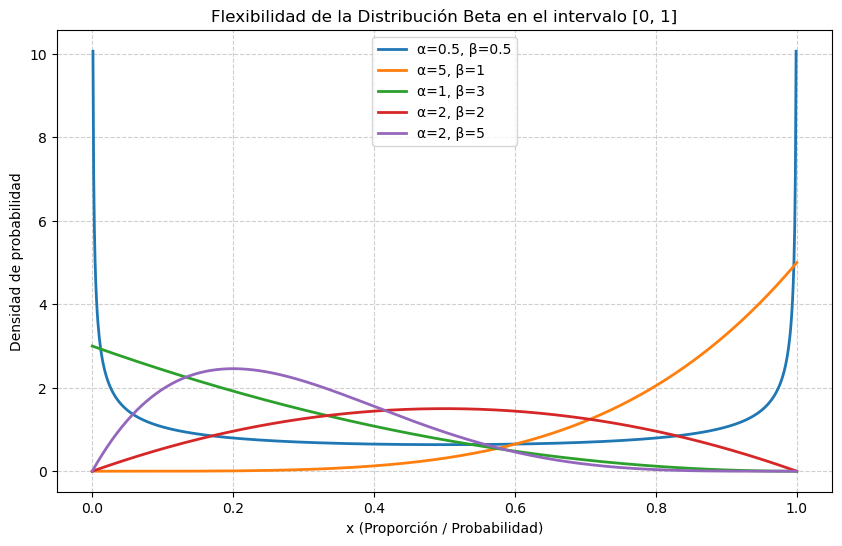

In [21]:
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt

# Definimos diferentes pares de (alpha, beta) para ver su flexibilidad
parametros = [(0.5, 0.5), (5, 1), (1, 3), (2, 2), (2, 5)]
x = np.linspace(0, 1, 1000)

plt.figure(figsize=(10, 6))

for a, b in parametros:
    y = beta.pdf(x, a, b)
    plt.plot(x, y, lw=2, label=f'α={a}, β={b}')

plt.title('Flexibilidad de la Distribución Beta en el intervalo [0, 1]')
plt.xlabel('x (Proporción / Probabilidad)')
plt.ylabel('Densidad de probabilidad')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

La selección de parámetros para una distribución Beta no es aleatoria; en actuaría solemos ajustarlos basándonos en nuestra **media esperada ($\mu$)** y **varianza ($\sigma^2$)** observadas en datos históricos:

* **Si esperas que el fenómeno se concentre en un punto:**
    * **$\alpha = \beta$**: Obtendrás una distribución simétrica centrada en 0.5. A mayor valor, menor varianza (la campana se vuelve más estrecha y "picuda").
    * **$\alpha > \beta$**: La distribución se desplaza hacia la derecha (valores cercanos a 1).
    * **$\alpha < \beta$**: La distribución se desplaza hacia la izquierda (valores cercanos a 0).

* **Intuición sobre la "fuerza" de los parámetros:**
    * **Valores pequeños ($\alpha, \beta < 1$):** Indican incertidumbre extrema o una "preferencia" por los extremos (forma en U).
    * **Valores grandes ($\alpha, \beta > 1$):** Indican que tenemos mucha confianza en la media, resultando en distribuciones más concentradas y estables.

En resumen, utiliza la distribución Beta cuando necesites modelar una variable que represente una **tasa de riesgo, una proporción de siniestralidad o un porcentaje de pérdida** donde los valores están naturalmente acotados entre 0 y 1.